# Setup and Environment

In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 59.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


## Library

In [2]:
import os
import torch
import ultralytics
from ultralytics import YOLO
from IPython.display import display, Image
from roboflow import Roboflow
import matplotlib.pyplot as plt
import cv2
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
print(f"Ultralytics version: {ultralytics.__version__}")

Ultralytics version: 8.4.33


## GPU Checking

In [ ]:
def check_env():
    gpu_ok = torch.cuda.is_available()
    gpu_count = torch.cuda.device_count()
    
    print(f"✅ GPU Terdeteksi: {gpu_ok}")
    if gpu_ok:
        for i in range(gpu_count):
            print(f"   - GPU {i}: {torch.cuda.get_device_name(i)}")
        
        try:
            import flash_attn
            print("✅ Flash Attention: Terinstal dan Siap")
        except ImportError:
            print("⚠️ Flash Attention: Tidak ditemukan (Training mungkin lebih lambat)")

check_env()

✅ GPU Terdeteksi: True
   - GPU 0: Tesla T4
   - GPU 1: Tesla T4
⚠️ Flash Attention: Tidak ditemukan (Training mungkin lebih lambat)


# Data Acquisition (Roboflow)

In [5]:
rf = Roboflow(api_key="DQi5rlMu5VCENFGOgfKS")
project = rf.workspace("ilhamfawwaz21s-workspace").project("roast-rojem")
version = project.version(2)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Roast-2 in yolov12:: 100%|██████████| 6519/6519 [00:00<00:00, 8679.24it/s] 


In [6]:
DATA_YAML_PATH = os.path.join(dataset.location, "data.yaml")

print("---")
print(f"Dataset berhasil diunduh ke: {dataset.location}")
print(f"Lokasi file: {DATA_YAML_PATH}")

---
Dataset berhasil diunduh ke: /kaggle/working/Roast-2
Lokasi file: /kaggle/working/Roast-2/data.yaml


# Initializing YOLOv12 Model & Training Process

In [ ]:
model = YOLO('yolo12s.pt')

model.train(
    data=DATA_YAML_PATH,    
    epochs=50,              
    imgsz=640,              
    batch=32,               
    name='coffee_model_v1', 
    device=[0, 1],          
    workers = 8,
    exist_ok=True,          
    amp = True
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Roast-2/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coffee_model_v1, nbs=64, nms=

# Evaluation and Metrics

In [8]:
RESULT_DIR = '/kaggle/working/runs/detect/coffee_model_v1'

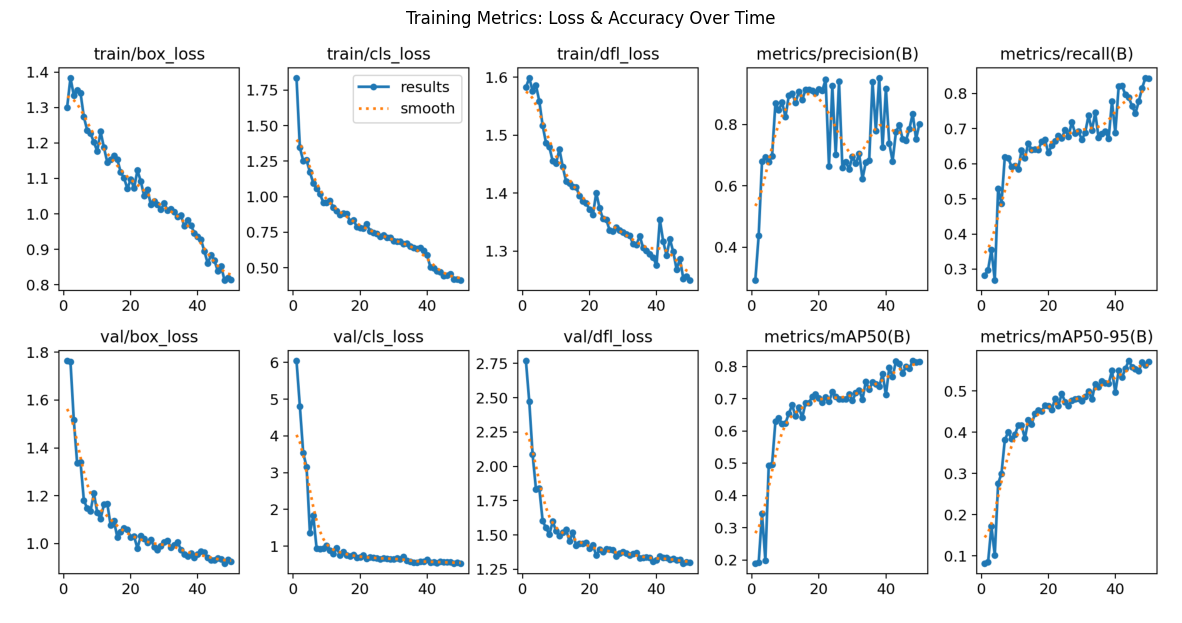

In [ ]:
if os.path.exists(f'{RESULT_DIR}/results.png'):
    plt.figure(figsize=(15, 10))
    results_img = cv2.imread(f'{RESULT_DIR}/results.png')
    plt.imshow(cv2.cvtColor(results_img, cv2.COLOR_BGR2RGB))
    plt.title("Training Metrics: Loss & Accuracy Over Time")
    plt.axis('off')
    plt.show()

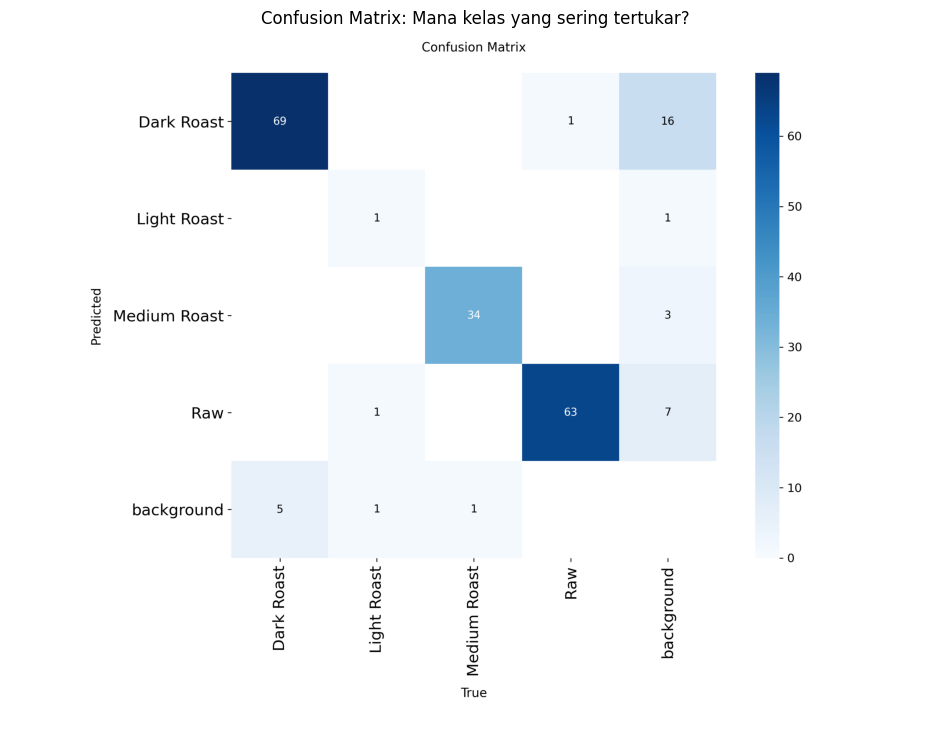

In [ ]:
if os.path.exists(f'{RESULT_DIR}/confusion_matrix.png'):
    plt.figure(figsize=(12, 12))
    cm_img = cv2.imread(f'{RESULT_DIR}/confusion_matrix.png')
    plt.imshow(cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB))
    plt.title("Confusion Matrix: Mana kelas yang sering tertukar?")
    plt.axis('off')
    plt.show()

In [ ]:
import os
import yaml
from collections import Counter

with open(DATA_YAML_PATH, 'r') as f:
    data_info = yaml.safe_load(f)
    class_names = data_info['names'] 

train_label_path = os.path.join(dataset.location, "valid/labels")

stats = Counter()
for label_file in os.listdir(train_label_path):
    if label_file.endswith('.txt'):
        with open(os.path.join(train_label_path, label_file), 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                stats[class_id] += 1

print("📊 DISTRIBUSI OBJEK DI DATA TRAIN:")
print("-" * 35)
for class_id, count in sorted(stats.items()):
    name = class_names[class_id]
    print(f"ID {class_id} | {name.ljust(15)} : {count} objek")

📊 DISTRIBUSI OBJEK DI DATA TRAIN:
-----------------------------------
ID 0 | Dark Roast      : 99 objek
ID 1 | Light Roast     : 11 objek
ID 2 | Medium Roast    : 90 objek
ID 3 | Raw             : 96 objek


# Inference (Test Set)

In [12]:
best_model = YOLO(f'{RESULT_DIR}/weights/best.pt')

In [13]:
results = best_model.predict(
    source=f"{dataset.location}/test/images", 
    conf=0.25, 
    save=True, 
    line_width=2
)


image 1/149 /kaggle/working/Roast-2/test/images/15329a40b134e94770ac5e3680346dcf_jpg.rf.20da70ce7ce980b0a59e60575d64b20e.jpg: 640x640 1 Medium Roast, 16.8ms
image 2/149 /kaggle/working/Roast-2/test/images/1df556dd69599503cb9630b0684cd3f4_jpg.rf.c8192cd528b791794ca8e301720466c8.jpg: 640x640 1 Light Roast, 16.7ms
image 3/149 /kaggle/working/Roast-2/test/images/4620693218556181706-49806cf62a41e44b9057f88a6a4d2b04-22031109_JPG.rf.45d86abf1a6648ab33788c9675b341db.jpg: 640x640 1 Dark Roast, 1 Raw, 16.7ms
image 4/149 /kaggle/working/Roast-2/test/images/4620693218556181706-5d20a841400240519cf0e7d0a9bd3f0f-22031109_JPG.rf.66f6a4f9c985547081acd61d7ca25f3d.jpg: 640x640 1 Dark Roast, 1 Raw, 16.7ms
image 5/149 /kaggle/working/Roast-2/test/images/4620693218556181706-7bf03c0424839ace8d8f81246caa232f-22031109_JPG.rf.250a1f637339d3c72ebfba1b3cc39957.jpg: 640x640 1 Dark Roast, 1 Raw, 16.7ms
image 6/149 /kaggle/working/Roast-2/test/images/4620693218556181706-802ff9e98addd7a9a529dfa5c7cdfcc5-22031109_JPG

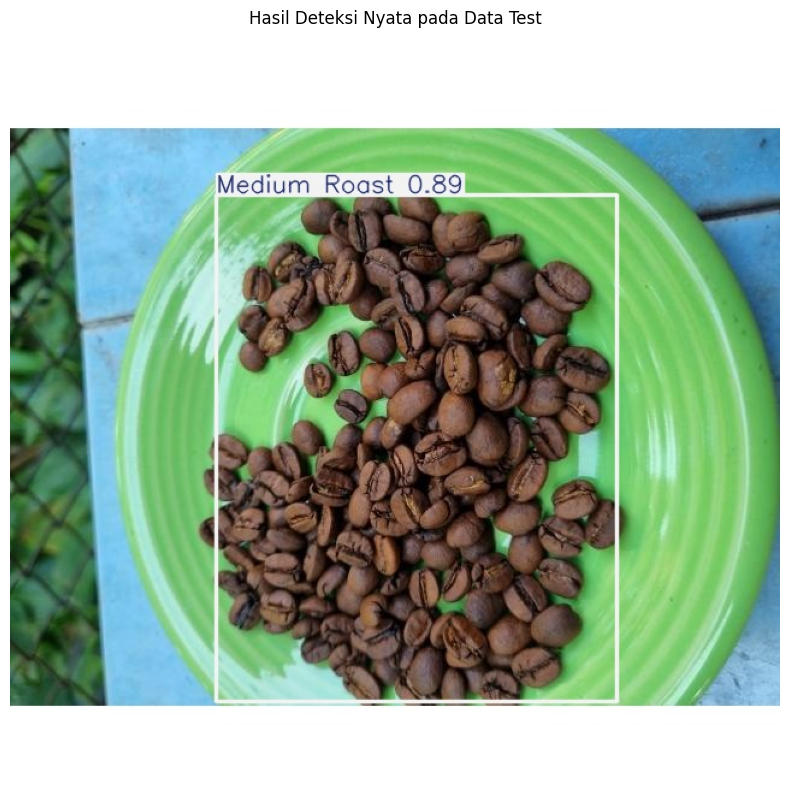

In [ ]:
predict_folders = sorted(glob.glob('/kaggle/working/runs/detect/predict*'))
latest_folder = predict_folders[-1]
sample_images = glob.glob(f'{latest_folder}/*.jpg')

if sample_images:
    plt.figure(figsize=(10, 10))
    sample_img = cv2.imread(sample_images[0])
    plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
    plt.title("Hasil Deteksi Nyata pada Data Test")
    plt.axis('off')
    plt.show()

# Save Model

In [15]:
print("--- TRAINING SELESAI ---")
print(f"File model 'best.pt' siap diunduh di: {RESULT_DIR}/weights/best.pt") 

--- TRAINING SELESAI ---
File model 'best.pt' siap diunduh di: /kaggle/working/runs/detect/coffee_model_v1/weights/best.pt
